In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import os

## data loading

In [2]:
df = pd.read_csv("data/multilabel_modified/multilabel_classification(7).csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7943 entries, 0 to 7942
Data columns (total 2 columns):
 #   Column                                                                                              Non-Null Count  Dtype
---  ------                                                                                              --------------  -----
 0   Image_Name                                                                                          7943 non-null   str  
 1    Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)  7943 non-null   str  
dtypes: str(2)
memory usage: 299.0 KB


In [4]:
df.columns

Index(['Image_Name', ' Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)'], dtype='str')

In [5]:
df.rename(columns= {' Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)' : "labels"}, inplace= True)

In [6]:
df.columns

Index(['Image_Name', 'labels'], dtype='str')

In [7]:
dir_ = "data/multilabel_modified/images"

In [8]:
imgs = set(os.listdir(dir_))

In [9]:
imgs

{'image1562.jpg',
 'image6575.jpg',
 'image2838.jpg',
 'image2490.jpg',
 'image7495.jpg',
 'image6246.jpg',
 'image1578.jpg',
 'image5229.jpg',
 'image2109.jpg',
 'image6347.jpg',
 'image77.jpg',
 'image7654.jpg',
 'image7165.jpg',
 'image3959.jpg',
 'image4363.jpg',
 'image6510.jpg',
 'image6598.jpg',
 'image5395.jpg',
 'image6493.jpg',
 'image4105.jpg',
 'image289.jpg',
 'image140.jpg',
 'image1243.jpg',
 'image4037.jpg',
 'image2514.jpg',
 'image3686.jpg',
 'image552.jpg',
 'image3220.jpg',
 'image125.jpg',
 'image3543.jpg',
 'image4716.jpg',
 'image4096.jpg',
 'image2723.jpg',
 'image5519.jpg',
 'image3651.jpg',
 'image7294.jpg',
 'image3149.jpg',
 'image2483.jpg',
 'image3540.jpg',
 'image5562.jpg',
 'image2710.jpg',
 'image4895.jpg',
 'image4853.jpg',
 'image2269.jpg',
 'image3410.jpg',
 'image6773.jpg',
 'image4151.jpg',
 'image3081.jpg',
 'image7789.jpg',
 'image7158.jpg',
 'image4475.jpg',
 'image7162.jpg',
 'image5638.jpg',
 'image7409.jpg',
 'image7590.jpg',
 'image3882.jpg'

In [10]:
df = df[df["Image_Name"].apply(lambda x: x in imgs)]

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7943 entries, 0 to 7942
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Image_Name  7943 non-null   str  
 1   labels      7943 non-null   str  
dtypes: str(2)
memory usage: 299.0 KB


## pre process

In [12]:
def img_preprocess(dirname):
    img = cv.imread(dirname)
    img = cv.resize(img, (150, 150))
    return img / 255.0

In [13]:
images = []
labels = []

for i, row in df.iterrows():
    img_name = row["Image_Name"]
    img_path = os.path.join(dir_, img_name)

    if os.path.exists(img_path):
        images.append(img_preprocess(img_path))
        labels.append(row["labels"].split())

In [14]:
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(labels)

In [15]:
mlb.classes_

array(['boat', 'bus', 'cycle', 'ektara', 'flutes', 'harmonium',
       'motorcycle', 'sitar', 'tabla', 'truck'], dtype=object)

In [16]:
labels

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 1, 0]], shape=(7943, 10))

In [17]:
labels_df = pd.DataFrame(data= labels, columns= mlb.classes_)

In [18]:
labels_df.head()

,boat,bus,cycle,ektara,flutes,harmonium,motorcycle,sitar,tabla,truck
0,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0


C:\Users\Win10\AppData\Local\Temp\ipykernel_13836\4083798618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= labels_df.iloc[:, 0], ax= axs.flatten()[0], palette= "Set1")
C:\Users\Win10\AppData\Local\Temp\ipykernel_13836\4083798618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= labels_df.iloc[:, 1], ax= axs.flatten()[1], palette= "Set1")
C:\Users\Win10\AppData\Local\Temp\ipykernel_13836\4083798618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= labels_df.iloc[:, 2], ax= axs.flatten()[2], palette= "Set1")
C:\Users\W

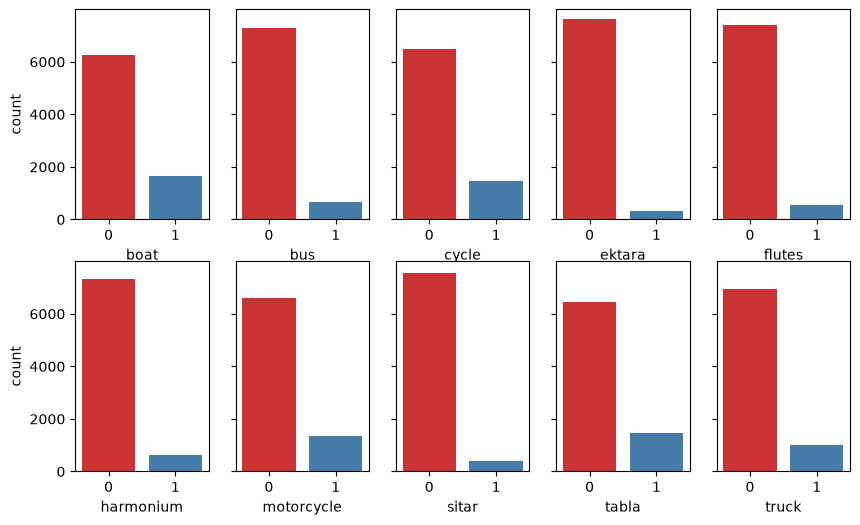

In [19]:
fig, axs = plt.subplots(nrows=2, ncols= 5, sharey= True)
fig.set_figwidth(10)
fig.set_figheight(6)
sns.countplot(x= labels_df.iloc[:, 0], ax= axs.flatten()[0], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 1], ax= axs.flatten()[1], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 2], ax= axs.flatten()[2], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 3], ax= axs.flatten()[3], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 4], ax= axs.flatten()[4], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 5], ax= axs.flatten()[5], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 6], ax= axs.flatten()[6], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 7], ax= axs.flatten()[7], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 8], ax= axs.flatten()[8], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 9], ax= axs.flatten()[9], palette= "Set1")
plt.show()

In [20]:
labels_df.sum(axis= 1).max()
# this means there are images whith at most 4 possible target

np.int64(4)

In [21]:
labels_df.sum(axis= 1).value_counts().index

Index([1, 2, 3, 4], dtype='int64')

C:\Users\Win10\AppData\Local\Temp\ipykernel_13836\3121619491.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= labels_df.sum(axis= 1).value_counts().index, y= labels_df.sum(axis= 1).value_counts().values, palette= "Set1")


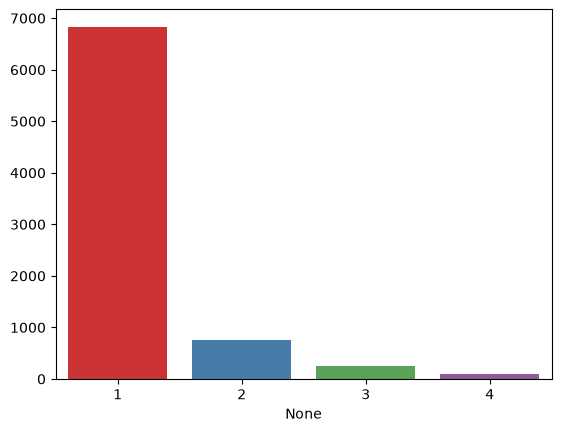

In [22]:
sns.barplot(x= labels_df.sum(axis= 1).value_counts().index, y= labels_df.sum(axis= 1).value_counts().values, palette= "Set1")
plt.show()

In [23]:
images = np.array(images)

In [24]:
type(images)

numpy.ndarray

In [25]:
images.dtype

dtype('float64')

In [26]:
type(labels)

numpy.ndarray

In [27]:
labels.dtype

dtype('int64')

In [ ]:
del df, imgs, dir_, mlb, labels_df, fig, axs, MultiLabelBinarizer, i, img_name, img_path, row, pd, plt, sns, cv, os

In [ ]:
X_train, X_val_test, y_train, y_val_test = train_test_split(images, labels, test_size= .3, shuffle= True, random_state= 12)

In [ ]:
del images, labels

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size= .5, shuffle= True, random_state= 12)

In [ ]:
del X_val_test, y_val_test

## model making

In [ ]:
model = tf.keras.models.Sequential(
    tf.keras.layers.Conv2D(32, (3, 3), padding= "same", activation= "relu", input_shape= (150, 150, 3)),
    tf.keras.layers.MaxPool2D(2, 2, padding= "same"),
    tf.keras.layers.Conv2D(64, (3, 3), padding= "valid", activation= "relu"),
    tf.keras.layers.MaxPool2D(2, 2, padding= "valid"),
    tf.keras.layers.Conv2D(128, (3, 3), padding= "valid", activation= "relu"),
    tf.keras.layers.MaxPool2D(2, 2, padding= "valid"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation= "relu"),
    tf.keras.layers.Dropout(.3),
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dropout(.3),
    tf.keras.layers.Dense(10, activation= "sigmoid")
)

In [ ]:
model.summary()

In [ ]:
tf.keras.utils.plot_model(model, show_shapes= True)

In [ ]:
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate= .001),
    loss= tf.keras.losses.SparseCategoricalCrossentropy,
    metrics= ["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor= "val_loss",
    patience= 10,
    restore_best_weights= True,
    verbose= 1,
    start_from_epoch= 2)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    batch_size= 2,
    epoch= 20,
    callbacks= [early_stop],
    validation_data= (X_val, y_val)
)

In [ ]:

# * saving model
# model.save("./models/{model_name}.keras")

In [1]:
import matplotlib.pyplot as plt

In [ ]:
history.params

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

In [ ]:

# * print validation loss and accuracy at early stopped epoch if happend otherwise print last epoch

# print(f"validation accuracy at epoch {epoch_index}: {val_accuracy[epoch_index - 1]}")
# print(f"validation loss at epoch {epoch_index}: {val_loss[epoch_index - 1]}")



In [ ]:
plt.figure(figsize= (10, 6))

plt.plot(accuracy, label= "train accuracy")
plt.plot(val_accuracy, label= "validation accuracy")

plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")

plt.legend(loc= "bottom right")
plt.show()

In [ ]:
plt.figure(figsize= (10, 6))

plt.plot(loss, label= "train loss")
plt.plot(val_loss, label= "validation loss")

plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.legend(loc= "bottom right")
plt.show()

In [ ]:
plt.figure(figsize= (10, 6))

plt.plot(accuracy, label= "train accuracy")
plt.plot(loss, label= "train loss")

plt.title("training accuracy - loss")
plt.xlabel("epoch")
plt.ylabel("accuracy - loss")

plt.legend(loc= "upper left")
plt.show()

In [ ]:
plt.figure(figsize= (10, 6))

plt.plot(val_accuracy, label= "validation accuracy")
plt.plot(val_loss, label= "validation loss")

plt.title("validation accuracy - loss")
plt.xlabel("epoch")
plt.ylabel("accuracy - loss")

plt.legend(loc= "upper left")
plt.show()

In [ ]:

# ? in case loading model is needed
# model = tf.keras.models.load_model("./models/{model_name}.keras")

## evaluating model

In [ ]:
model.evaluate(X_val, y_val, batch_size= 2)

In [ ]:
model.evaluate(X_test, y_test, batch_size= 2)

In [ ]:
y_pred = model.predict(X_test, batch_size= 2)

In [ ]:
y_pred = (y_pred >= .5).astype(np.int_)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
print(classification_report(y_test, y_pred))
# classification_report(y_test, y_pred, targets_name= mlb.classes_) # ! need to preprocess the data again to pass as parameter, run below to preprocess

In [ ]:
del X_train, y_train, X_val, y_val

import pandas as pd
import os
from sklearn.preprocessing import MultiLabelBinarizer

df = pd.read_csv("data/multilabel_modified/multilabel_classification(7).csv")

df.rename(columns= {' Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)' : "labels"}, inplace= True)

dir_ = "data/multilabel_modified/images/"

imgs = set(os.listdir(dir_))

df = df[df["Image_Name"].apply(lambda x: x in imgs)]

labels = []

for i, row in df.iterrows():
    img_name = row["Image_Name"]
    img_path = os.path.join(dir_, img_name)

    if os.path.exists(img_path):
        labels.append(row["labels"].split())

mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(labels)

print(classification_report(y_test, y_pred, target_names= mlb.classes_))